# Cross-Sectional Momentum Strategy (12-1) on S&P 500

**Author:** Ayaan Khalid

---

## Overview

This project implements a **long-only cross-sectional momentum strategy** based on Jegadeesh & Titman (1993)

### Core Idea
Stocks that have performed well over the past year tend to continue outperforming over the next month. By systematically buying recent winners and avoiding recent losers, momentum strategies aim to capture this effect.

### Strategy: 12-1 Month Momentum
- Each month, compute the **12-1 momentum score** for every stock in the S&P 500 which is the cumulative return from 12 months ago to 1 month ago (skipping the most recent month to avoid short-term reversal)
- Rank all stocks by their momentum score
- **Buy the top decile** (~48 stocks), equal weighted
- **Rebalance monthly**, accounting for transaction costs
- Benchmark against SPY buy & hold

### Why skip the most recent month?
The very short-term (1 month) exhibits **mean reversion** rather than momentum as stocks that just spiked tend to pull back. Excluding it produces a cleaner signal.

### Why cross-sectional?
Unlike time-series momentum (betting on whether a single asset goes up or down), cross-sectional momentum ranks assets *relative to each other*.

## 1. Imports & Setup

In [1]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-darkgrid')
plt.rcParams['figure.dpi'] = 120

## 2. Universe: S&P 500 Tickers

We pull the current S&P 500 constituent list from a public dataset. Note this introduces a degree of **survivorship bias** as we are using today's list rather than the historical composition at each rebalance date. Stocks that were delisted or removed from the index during the backtest period are excluded.

In [2]:
sp500 = pd.read_csv('https://raw.githubusercontent.com/datasets/s-and-p-500-companies/main/data/constituents.csv')
tickers = sp500['Symbol'].tolist()
tickers = [t.replace('.', '-') for t in tickers]  #yfinance uses dashes

print(f"Total tickers: {len(tickers)}")
print(tickers[:10])

Total tickers: 503
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


## 3. Data

We download 7.5 years of daily closing prices (2019–2026). We start from 2019 because the 12-month momentum signal requires a full year of lookback. The first usable signal appears in early 2020, giving approximately 6.5 years of live trading.

After downloading, we drop tickers with more than 10% missing data and forward-fill small gaps (e.g. trading halts).

In [3]:
raw = yf.download(tickers, start="2019-01-01", end="2026-06-01", auto_adjust=True)
prices = raw["Close"]

print(f"Raw shape: {prices.shape}")

#drop tickers with too much missing data
threshold = len(prices) * 0.9
prices = prices.dropna(axis=1, thresh=threshold)

#forward fill remaining small gaps
prices = prices.ffill()

print(f"Tickers remaining after cleaning: {prices.shape[1]}")

[*********************100%***********************]  503 of 503 completed


Raw shape: (1862, 503)
Tickers remaining after cleaning: 485


## 4. Signal Generation: 12-1 Momentum

We resample daily prices to **monthly** (last trading day of each month), compute monthly returns, then calculate the 12-1 momentum score as the sum of the past 11 monthly returns, shifted by 1 month to exclude the most recent.

In [4]:
#resample to monthly prices
monthly_prices = prices.resample('M').last()

#monthly returns
monthly_returns = monthly_prices.pct_change()

#12-1 momentum --> sum of returns from month -12 to -1 (skip most recent)
momentum = monthly_returns.shift(1).rolling(11).sum()

print(f"Momentum signal shape: {momentum.shape}")
print(momentum.tail())

Momentum signal shape: (89, 485)
Ticker             A      AAPL      ABBV       ABT      ACGL       ACN  \
Date                                                                     
2026-01-31 -0.056498  0.166274  0.267018  0.004678  0.043155 -0.326409   
2026-02-28  0.084700  0.094863  0.114237 -0.197320  0.046125 -0.249090   
2026-03-31  0.077058  0.195429  0.152564 -0.093981  0.053724 -0.352785   
2026-04-30  0.096466  0.199453  0.149916 -0.201799  0.069371 -0.366201   
2026-05-31  0.070092  0.322228  0.175687 -0.333606  0.005351 -0.516370   

Ticker          ADBE       ADI       ADM       ADP  ...        WY      WYNN  \
Date                                                ...                       
2026-01-31 -0.196811  0.303856  0.176030 -0.128358  ... -0.209095  0.380360   
2026-02-28 -0.361467  0.364417  0.415200 -0.208992  ... -0.103890  0.242041   
2026-03-31 -0.341155  0.628466  0.431472 -0.315053  ... -0.131941  0.316283   
2026-04-30 -0.392525  0.558915  0.489756 -0.343240  .

## 5. Backtester: Monthly Rebalancing with Transaction Costs

Each month we:
1. Rank all stocks by their momentum score
2. Select the top decile (~48 stocks)
3. Compare to the previous month's holdings to identify buys and sells
4. Deduct transaction costs of **0.1% per trade** (one-way) which is a realistic estimate for modern US equity markets
5. Record the net equal-weighted portfolio return for the following month

Transaction costs matter here because monthly rebalancing generates significant turnover as stocks rotate in and out of the top decile each month.

In [5]:
transaction_cost = 0.001  #0.1% per trade one-way
n_stocks = int(prices.shape[1] * 0.1)  #top 10% ~ 48 stocks

portfolio_returns = []
dates = []
prev_holdings = set()

for date in momentum.index[12:]:  #skip warmup period
    scores = momentum.loc[date].dropna()

    if len(scores) < n_stocks:
        continue

    top_decile = set(scores.nlargest(n_stocks).index.tolist())

    #identify trades
    sold = prev_holdings - top_decile
    bought = top_decile - prev_holdings

    #transaction cost as fraction of portfolio
    turnover_cost = (len(sold) + len(bought)) * transaction_cost / n_stocks

    next_idx = monthly_returns.index.get_loc(date) + 1
    if next_idx >= len(monthly_returns):
        continue
    next_month = monthly_returns.index[next_idx]

    gross_return = monthly_returns.loc[next_month, list(top_decile)].mean()
    net_return = gross_return - turnover_cost

    portfolio_returns.append(net_return)
    dates.append(next_month)
    prev_holdings = top_decile

port = pd.Series(portfolio_returns, index=dates)
print(f"Months traded: {len(port)}")
print(port.tail())

Months traded: 76
2026-01-31    0.102724
2026-02-28    0.082364
2026-03-31   -0.069344
2026-04-30    0.247757
2026-05-31    0.090393
dtype: float64


## 6. Benchmark: SPY Buy & Hold

We download SPY over the same period and compute monthly returns to benchmark against the strategy.

In [6]:
spy = yf.download("SPY", start=port.index[0], end=port.index[-1], auto_adjust=True)["Close"]
spy_monthly = spy.resample('M').last()
spy_returns = spy_monthly.pct_change().dropna()
spy_returns = spy_returns.reindex(port.index).dropna()

[*********************100%***********************]  1 of 1 completed


## 7. Performance Metrics

We evaluate both strategies on four key metrics. Sharpe ratio uses `√12` (not `√252`) as we are working with **monthly** returns.

| Metric | Description |
|--------|-------------|
| **Final Value** | Portfolio value at end of period |
| **Total PnL** | Profit or loss in dollars |
| **Sharpe Ratio** | Return per unit of risk (annualised) |
| **Max Drawdown** | Worst peak-to-trough decline |


In [7]:
def compute_metrics(returns, capital=10000):
    cumulative = (1 + returns).cumprod() * capital
    final = float(cumulative.iloc[-1])
    pnl = final - capital
    sharpe = float(returns.mean() / returns.std() * np.sqrt(12))
    rolling_max = cumulative.cummax()
    max_dd = float(((cumulative - rolling_max) / rolling_max).min())
    return final, pnl, sharpe, max_dd

port_final, port_pnl, port_sharpe, port_dd = compute_metrics(port)
spy_final, spy_pnl, spy_sharpe, spy_dd = compute_metrics(spy_returns)

#cumulative value series for plotting
cumulative_port = (1 + port).cumprod() * 10000
cumulative_spy = (1 + spy_returns).cumprod() * 10000

print(f"{'Metric':<20} {'Momentum':>15} {'SPY B&H':>15}")
print("-" * 52)
print(f"{'Final Value':<20} ${port_final:>14,.2f} ${spy_final:>14,.2f}")
print(f"{'Total PnL':<20} ${port_pnl:>14,.2f} ${spy_pnl:>14,.2f}")
print(f"{'Sharpe Ratio':<20} {port_sharpe:>15.2f} {spy_sharpe:>15.2f}")
print(f"{'Max Drawdown':<20} {port_dd:>15.2%} {spy_dd:>15.2%}")

Metric                      Momentum         SPY B&H
----------------------------------------------------
Final Value          $     59,059.39 $     31,927.81
Total PnL            $     49,059.39 $     21,927.81
Sharpe Ratio                    1.26            1.25
Max Drawdown                 -18.25%         -23.93%


## 8. Visualisation

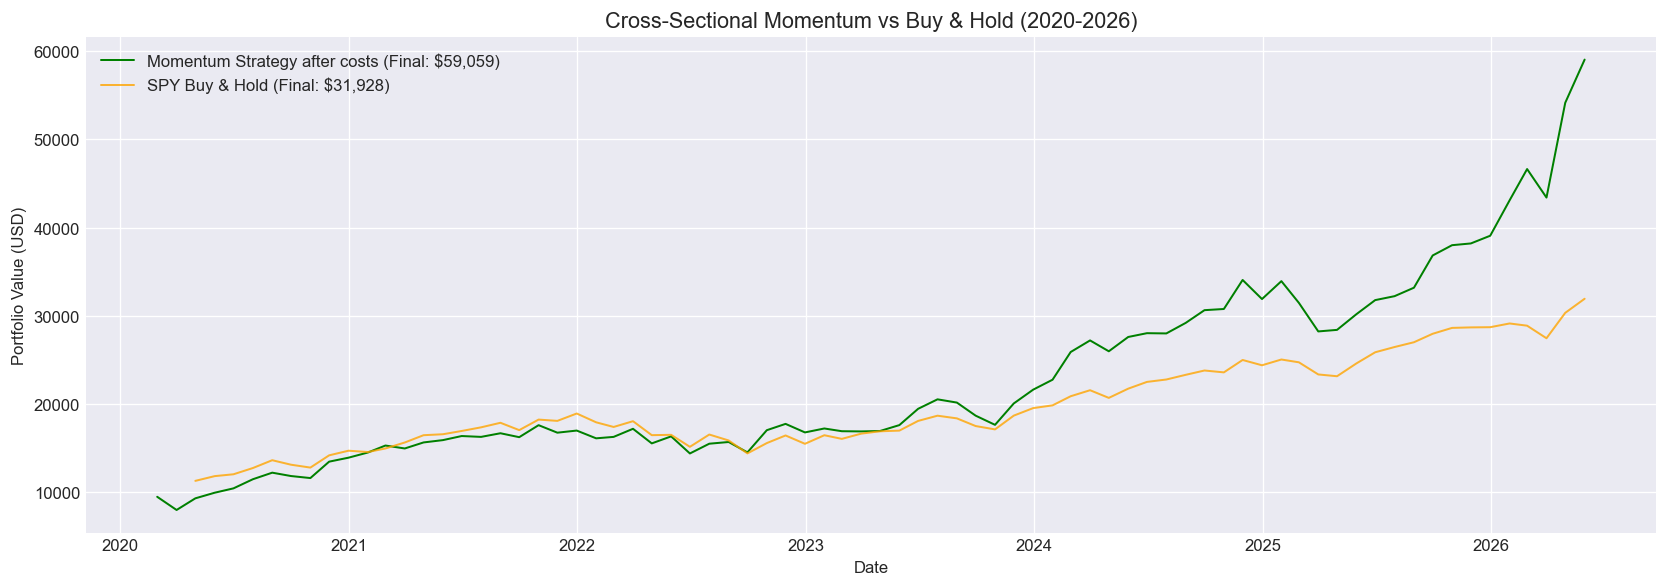

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(cumulative_port, color="green", label=f"Momentum Strategy after costs (Final: ${port_final:,.0f})", linewidth=1.2)
ax.plot(cumulative_spy, color="orange", label=f"SPY Buy & Hold (Final: ${spy_final:,.0f})", linewidth=1.2, alpha=0.8)

ax.set_title("Cross-Sectional Momentum vs Buy & Hold (2020-2026)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value (USD)")
ax.legend()

plt.tight_layout()
plt.show()

## 9. Conclusion

### Results Summary
The momentum strategy **outperformed buy & hold on total return** over the 2020-2026 period, while also achieving a lower max drawdown. The strategy recovered faster from the 2022 bear market and pulled clearly ahead from 2023 onwards. Performance remained positive even after accounting for transaction costs, suggesting the momentum effect is robust to realistic trading frictions.

### Why does momentum work?
There are two competing explanations:
- **Behavioural:** Investors underreact to good news initially, causing prices to drift upward gradually as more participants take notice
- **Risk-based:** Momentum stocks may carry higher systematic risk that justifies the excess return


### Limitations
- **Survivorship bias:** The stock universe uses today's S&P 500 constituents. Stocks that were delisted or removed during the backtest period are excluded, which artificially inflates returns. A rigorous backtest would use point-in-time constituent data.
- **Momentum crashes:** The strategy is known to suffer severe drawdowns during sharp market reversals (e.g. post-COVID rebound in 2020) when recent losers suddenly outperform. This is visible in the early 2020 dip.
- **Long-only:** The classic strategy shorts the bottom decile as well, which would improve risk-adjusted returns but requires margin and introduces short-squeeze risk.
- **Equal weighting:** A more sophisticated implementation would size positions by signal strength or use volatility-adjusted weights.
- **Transaction costs simplified:** Costs are modelled as a fixed percentage. In reality they vary by stock liquidity, trade size, and market conditions.